In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr 
import pickle

In [2]:
final_df = pd.read_pickle('final_df3.pkl')
print(final_df.columns)

Index(['Year', 'Temp_DJF', 'Precip_DJF', 'Temp_MJJAS', 'Precip_MJJAS',
       'GlacierId', 'Glacier', 'Bs', 'Bw', 'Ba', 'Region', 'Cumulative_Ba',
       'Rolling_Bs', 'Rolling_Bw', 'Period', 'PC1_DJF', 'PC1_MJJAS', 'PC1_AO',
       'SSRD_DJF', 'SSRD_MJJAS', 'u10_DJF', 'u10_MJJAS', 'v10_DJF',
       'v10_MJJAS', 'NAO_Hurell', 'GlacierShort', 'EA_DJF', 'EA_MJJAS'],
      dtype='object')


In [3]:
results= []

for glacier, group in final_df.groupby('GlacierShort'):
    #group= group.dropna(subset=['Ba', 'Bs', 'Bw', 'Year'])
    pre2000  = group[group['Year'] < 2000]
    post2000 = group[group['Year'] >= 2000]

    if len(pre2000)> 5 and len(post2000) > 5:
        r_pre2k_bw, p_pre2k_bw= pearsonr(pre2000['Bw'], pre2000['Ba'])
        r_post2k_bw, p_post2k_bw= pearsonr(post2000['Bw'], post2000['Ba'])

        r_pre2k_bs, p_pre2k_bs= pearsonr(pre2000['Bs'], pre2000['Ba'])
        r_post2k_bs, p_post2k_bs= pearsonr(post2000['Bs'], post2000['Ba'])

        results.append({
            'Glacier': glacier,
            'Pre2000_Ba~Bw_r': r_pre2k_bw,
            'Pre2000_Ba~Bw_p': p_pre2k_bw,

            'Post2000_Ba~Bw_r': r_post2k_bw,
            'Post2000_Ba~Bw_p': p_post2k_bw,

            'Pre2000_Ba~Bs_r': r_pre2k_bs,
            'Pre2000_Ba~Bs_p': p_pre2k_bs,

            'Post2000_Ba~Bs_r': r_post2k_bs,
            'Post2000_Ba~Bs_p': p_post2k_bs
        }) 
        
corr_df = pd.DataFrame(results)


In [4]:
print(corr_df)

   Glacier  Pre2000_Ba~Bw_r  Pre2000_Ba~Bw_p  Post2000_Ba~Bw_r  \
0      Alf         0.854138     1.788535e-11          0.850235   
1      Aus         0.749342     5.024158e-03          0.871304   
2      Eng         0.727702     5.195745e-06          0.847848   
3     Graf         0.747607     5.336419e-02          0.669666   
4     Gras         0.528560     6.466156e-04          0.637781   
5      Han         0.791461     7.450840e-04          0.836645   
6     Hell         0.586618     1.085408e-04          0.705000   
7      Lan         0.750955     1.969682e-02          0.403845   
8      Nig         0.717485     3.995512e-07          0.825832   
9      Rem         0.832508     1.677150e-10          0.868739   
10     Sto         0.723656     4.236310e-09          0.729004   

    Post2000_Ba~Bw_p  Pre2000_Ba~Bs_r  Pre2000_Ba~Bs_p  Post2000_Ba~Bs_r  \
0       2.797914e-07         0.575176     1.961824e-04          0.829993   
1       6.275334e-08         0.614352     3.355019e-02 

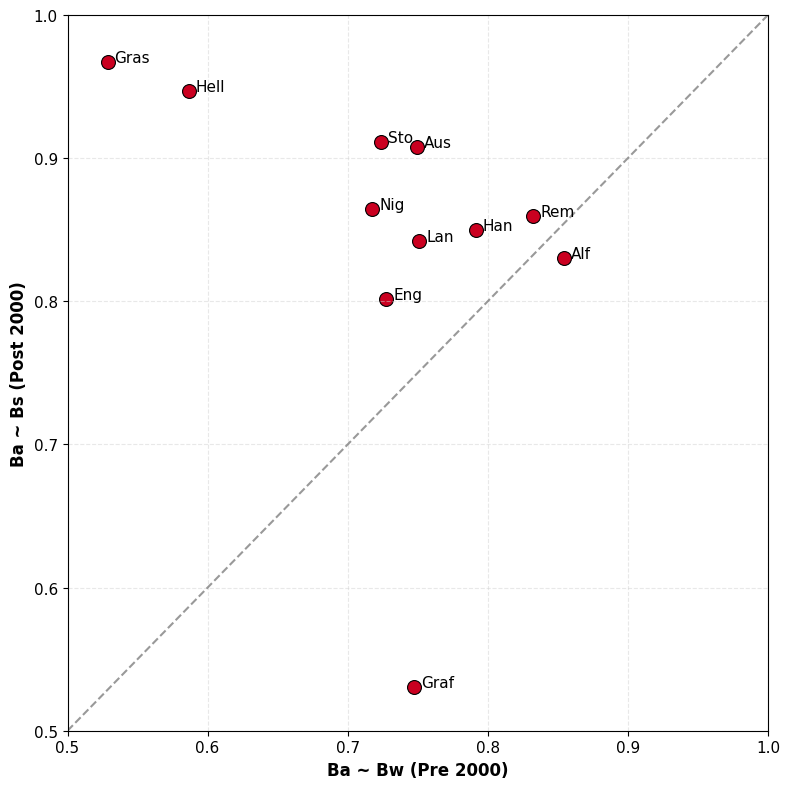

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot
sns.scatterplot(data=corr_df, 
                x="Pre2000_Ba~Bw_r", 
                y="Post2000_Ba~Bs_r", 
                s=100, 
                color="#ca0020",  # "#ca0020"
                edgecolor="black")

# zero line 
plt.axline((0, 0), slope=1, linestyle="--", color="grey", alpha=0.8)

# Labels & titles
plt.xlabel("Ba ~ Bw (Pre 2000)", fontsize=12, fontweight='bold')
plt.ylabel("Ba ~ Bs (Post 2000)", fontsize=12, fontweight='bold')
#plt.title("Shift from Winter to Summer Dominated MB Control", fontsize=14, fontweight='bold')

# Glacier names as point labels
for i, row in corr_df.iterrows():
    plt.text(row["Pre2000_Ba~Bw_r"] + 0.005,  # X offset to avoid overlap
             row["Post2000_Ba~Bs_r"],
             row["Glacier"],
             fontsize=11)

# Grid, ticks
gridline_color = "#d3d3d3"
plt.grid(True, linestyle="--", alpha=0.5, color=gridline_color)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
ax.set_xlim(0.5, 1)
ax.set_ylim(0.5, 1)

plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\10- Discussion Plots\Scatter_Shift_BaBw_to_BaBs.png", dpi=800, bbox_inches="tight")
plt.show()


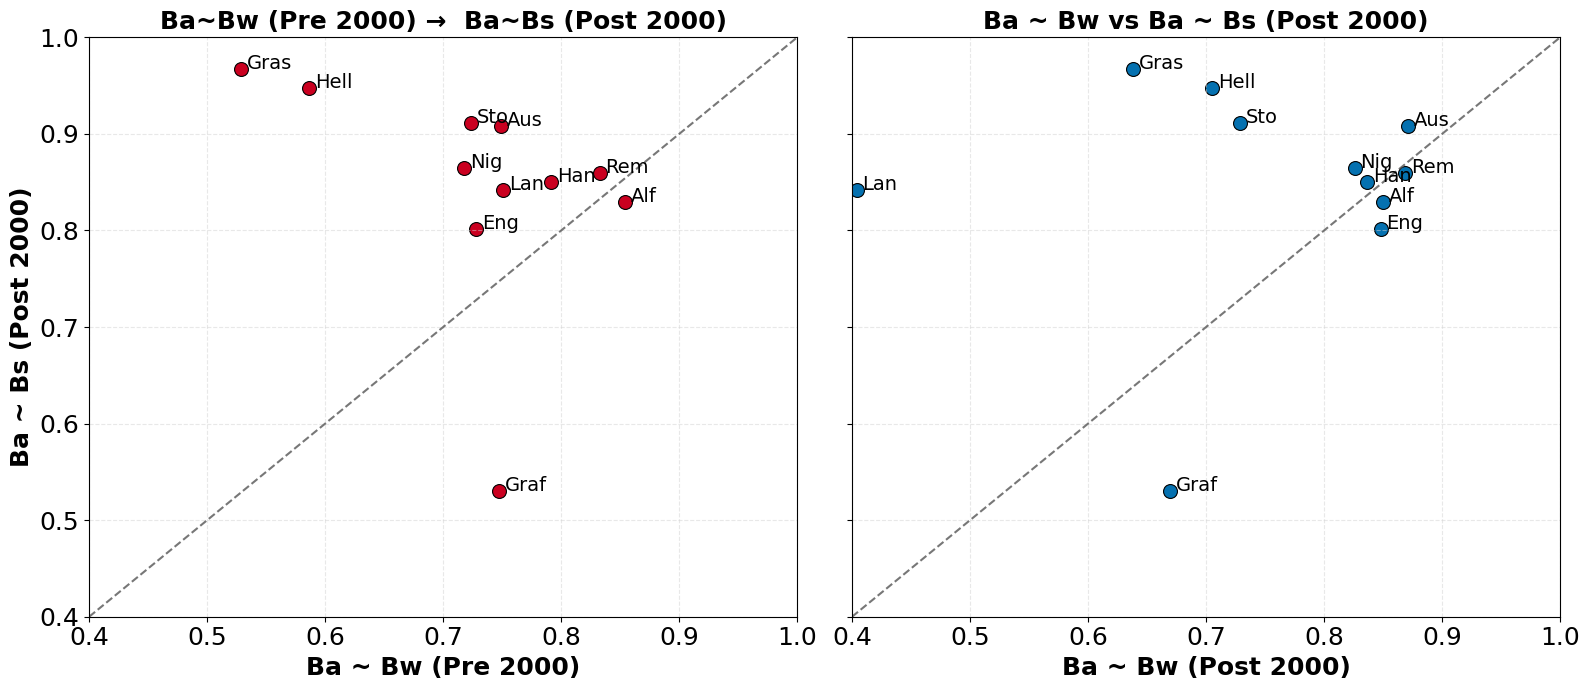

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# === Plot A: Pre2000 Ba~Bw vs Post2000 Ba~Bs ===
sns.scatterplot(data=corr_df,
                x="Pre2000_Ba~Bw_r",
                y="Post2000_Ba~Bs_r",
                s=100, color="#ca0020", edgecolor="black",
                ax=axes[0])

axes[0].axline((0, 0), slope=1, linestyle="--", color="#555555", alpha=0.8)
axes[0].set_title("Ba~Bw (Pre 2000) →  Ba~Bs (Post 2000)", fontsize=18, fontweight='bold')
axes[0].set_xlabel("Ba ~ Bw (Pre 2000)", fontsize=18, fontweight='bold')
axes[0].set_ylabel("Ba ~ Bs (Post 2000)", fontsize=18, fontweight='bold')

for i, row in corr_df.iterrows():
    axes[0].text(row["Pre2000_Ba~Bw_r"] + 0.005, row["Post2000_Ba~Bs_r"],
                 row["Glacier"], fontsize=14)

# === Plot B: Post2000 Ba~Bw vs Ba~Bs ===
sns.scatterplot(data=corr_df,
                x="Post2000_Ba~Bw_r",
                y="Post2000_Ba~Bs_r",
                s=100, color="#0571b0", edgecolor="black",
                ax=axes[1])

axes[1].axline((0, 0), slope=1, linestyle="--", color="#555555", alpha=0.8)
axes[1].set_title("Ba ~ Bw vs Ba ~ Bs (Post 2000)", fontsize=18, fontweight='bold')
axes[1].set_xlabel("Ba ~ Bw (Post 2000)", fontsize=18, fontweight='bold')
axes[1].set_ylabel("Ba ~ Bs (Post 2000)", fontsize=18, fontweight='bold')

# Annotate glacier names
for i, row in corr_df.iterrows():
    axes[1].text(row["Post2000_Ba~Bw_r"] + 0.005, row["Post2000_Ba~Bs_r"],
                 row["Glacier"], fontsize=14)
    

# === Styling ===
for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.5, color="#d3d3d3")
    ax.tick_params(axis='both', labelsize=18)
    ax.set_xlim(0.4, 1)
    ax.set_ylim(0.4, 1)

plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\10- Discussion Plots\2Scatter_Shift_Comparison.png", dpi=800, bbox_inches='tight')
plt.show()


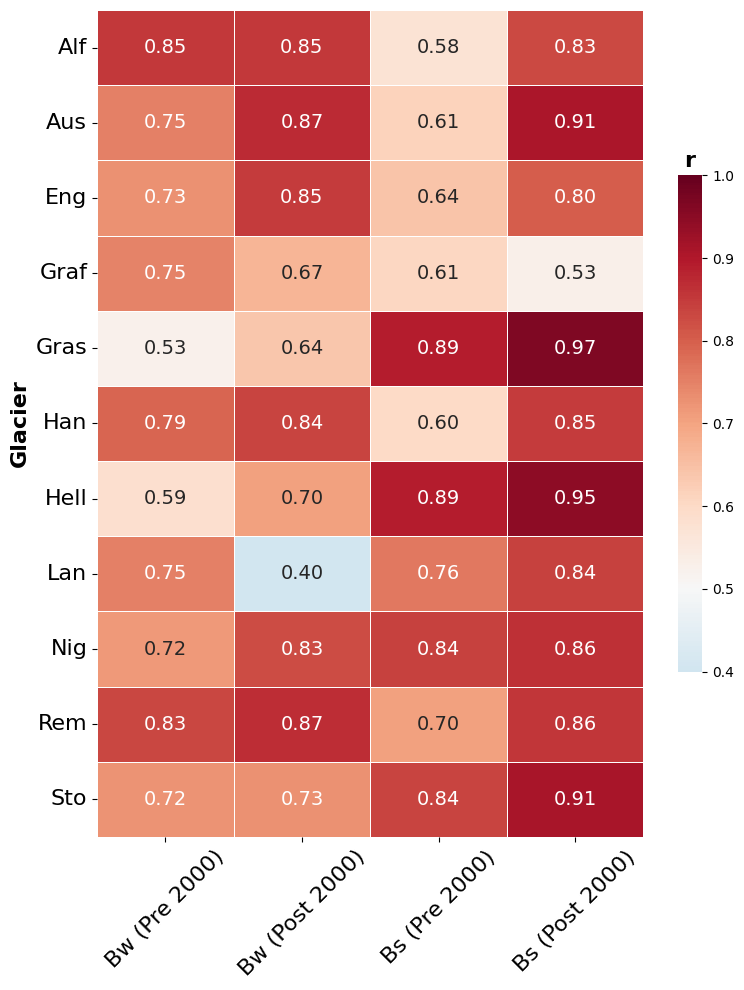

In [ ]:
# structure the data
heatmap_data = corr_df.set_index("Glacier")[[
    "Pre2000_Ba~Bw_r", "Post2000_Ba~Bw_r",
    "Pre2000_Ba~Bs_r", "Post2000_Ba~Bs_r"
]]

heatmap_data = heatmap_data.rename(columns={
    "Pre2000_Ba~Bw_r": "Bw (Pre 2000)",
    "Post2000_Ba~Bw_r": "Bw (Post 2000)",
    "Pre2000_Ba~Bs_r": "Bs (Pre 2000)",
    "Post2000_Ba~Bs_r": "Bs (Post 2000)"
})

# Plot
fig, ax = plt.subplots(figsize=(8, 10))

sns.heatmap(heatmap_data,
            annot=True, 
            cmap="RdBu_r", 
            center=0.5,
            fmt=".2f", 
            linewidths=0.5, 
            cbar=True,
            vmax= 1,
            vmin= 0.4,
            cbar_kws= {
            'shrink': 0.6,       # Shrink the colorbar height to 50%
            'aspect': 20,        
            'pad': 0.05,        # Padding between heatmap and colorbar
            },
            annot_kws={"fontsize": 14})

cbar = ax.collections[0].colorbar
cbar.ax.set_title('r', fontsize=16, weight='bold', pad=6, loc='center')

#plt.title("Correlation of Ba with Bw and Bs (Pre/Post 2000)", fontsize=12, fontweight='bold')
plt.ylabel("Glacier", fontsize=16, fontweight='bold')

ax.tick_params(axis='y', labelsize=16)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=16)
ax.tick_params(axis='x', labelsize=16, rotation=45)
plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\10- Discussion Plots\ba_bs_bw_correlation.png", dpi=800, bbox_inches='tight')
plt.show()


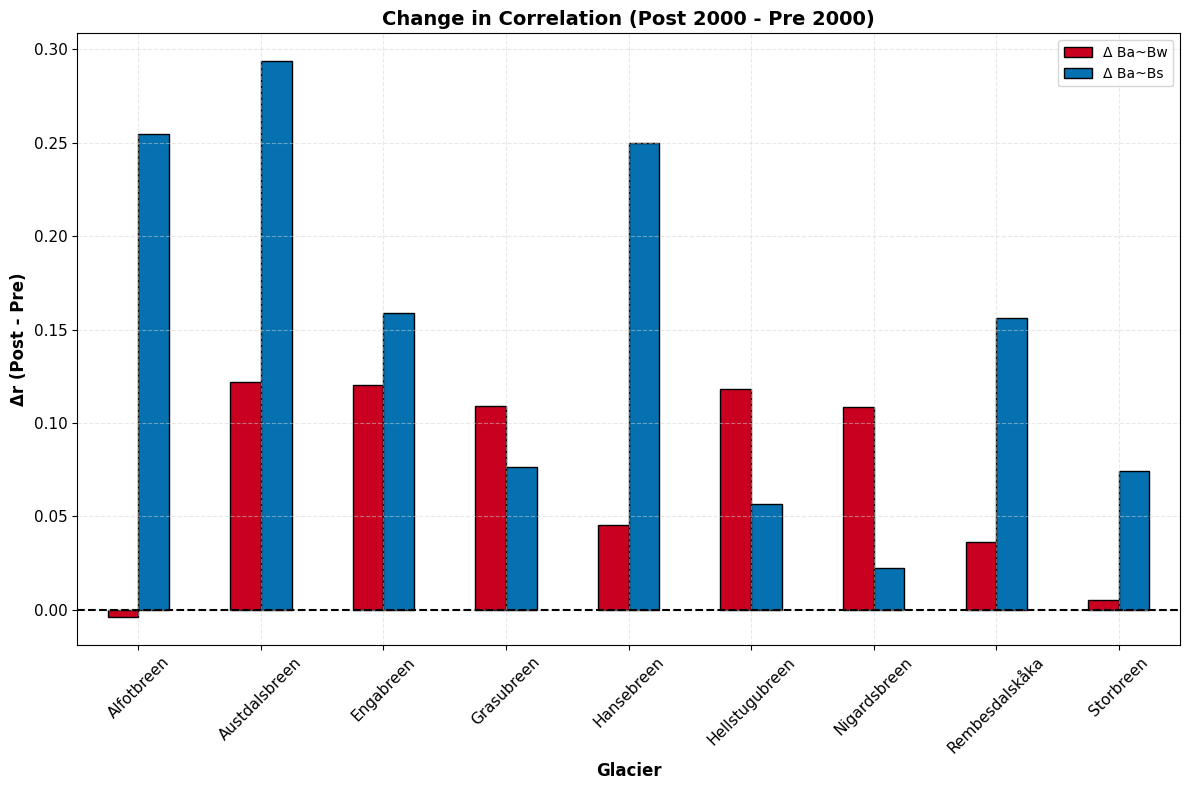

In [ ]:
# Add delta columns
corr_df["Δ Ba~Bw"] = corr_df["Post2000_Ba~Bw_r"] - corr_df["Pre2000_Ba~Bw_r"]
corr_df["Δ Ba~Bs"] = corr_df["Post2000_Ba~Bs_r"] - corr_df["Pre2000_Ba~Bs_r"]

# Extract delta-only DataFrame
delta_df = corr_df[["Glacier", "Δ Ba~Bw", "Δ Ba~Bs"]].set_index("Glacier")

# Plot
gridline_color = "#d3d3d3"

delta_df.plot(kind="bar", figsize=(12, 8), edgecolor="black", color=["#ca0020", "#0571b0"])
plt.axhline(0, color="black", linestyle="--")
plt.title("Change in Correlation (Post 2000 - Pre 2000)", fontsize=14, fontweight='bold')
plt.ylabel("Δr (Post - Pre)", fontsize=12, fontweight='bold')
plt.xlabel('Glacier', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11, rotation=45)
plt.yticks(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5, color= gridline_color)

plt.tight_layout()
#plt.savefig('Delta_Correlation_barplot.png', dpi=800, bbox_inches='tight')
plt.show()
